# 💳 Credit Card Fraud Detection

This notebook walks through a complete analysis of real-world credit card transactions to automatically detect fraud. Fraud makes up less than 0.2% of all transactions, so the challenge is finding those rare cases without flagging too many normal purchases.

### What We Do, Step by Step:
1. **Load & Clean Data** — Remove duplicate records and fix any missing information.
2. **Explore the Data** — Use charts to understand what normal vs. fraudulent transactions look like.
3. **Check Data Quality** — Make sure our data columns aren't feeding the models the same information twice.
4. **Prepare the Data** — Scale numbers to a common range and remove extreme outliers.
5. **Fix the Imbalance** — Since fraud is rare, we use techniques to give models enough fraud examples to learn from.
6. **Train Multiple Models** — Test several algorithms from simple to advanced and compare their results.
7. **Evaluate & Compare** — Measure every model on Accuracy, Precision, Recall, F1-Score, and more.
8. **Fine-Tune** — Adjust settings to squeeze the best possible fraud detection performance.

---
## 📦 Dependency Setup
This section installs all the necessary software libraries required to run the code in this notebook.

In [72]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn statsmodels imbalanced-learn xgboost lightgbm plotly

---
## 🏗️ Section 1 — Setup & Data Ingestion
We load the credit card transaction dataset and perform an initial check to see how many transactions are fraudulent versus normal. We also check for and remove any duplicate or missing records to ensure our models learn from clean data.

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import plotly.express as px
import math
from collections import Counter

# Preprocessing & Metrics
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.metrics import (
    precision_recall_curve, average_precision_score, f1_score, 
    confusion_matrix, classification_report, roc_auc_score, accuracy_score
)

# Statistical Validation
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Balancing & Models
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Deep Learning
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping
    HAS_TF = True
except ImportError:
    print('⚠️ TensorFlow not found or unsupported by Python 3.14. Falling back to Scikit-Learn MLP.')
    from sklearn.neural_network import MLPClassifier
    HAS_TF = False

# Visual settings
%matplotlib inline
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (12, 6)
warnings.filterwarnings('ignore')

⚠️ TensorFlow not found or unsupported by Python 3.14. Falling back to Scikit-Learn MLP.


In [74]:
# Load dataset from standard data directory
data_path = 'data/creditcard.csv'
try:
    df = pd.read_csv(data_path)
    print(f"✅ Dataset loaded from {data_path}")
except FileNotFoundError:
    # Attempting common paths for diverse environments
    possible_paths = ['/data/creditcard.csv']
    found = False
    for p in possible_paths:
        if os.path.exists(p):
            df = pd.read_csv(p)
            print(f"✅ Dataset loaded from {p}")
            found = True
            break
    if not found:
        print("❌ Error: Dataset not found. Please ensure 'data/creditcard.csv' exists.")

# Initial Audit
print(f"Dataset Shape: {df.shape}")
print(f"Total Fraud Transactions: {df['Class'].sum()}")

# Deduplication
initial_len = len(df)
df.drop_duplicates(inplace=True)
print(f"Dropped {initial_len - len(df)} duplicates.")

# Missing Values Audit
if df.isnull().sum().max() == 0:
    print("✅ No missing values detected.")
else:
    print("⚠️ Missing values found. Dropping rows with NaNs.")
    df.dropna(inplace=True)

df.head()

✅ Dataset loaded from data/creditcard.csv
Dataset Shape: (284807, 31)
Total Fraud Transactions: 492
Dropped 1081 duplicates.
✅ No missing values detected.


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


---
## 📊 Section 2 — Visual Data Analysis
Here, we create various charts to understand our data better. By visualizing features like the 'Amount' and 'Time' of transactions, we can start to see patterns that might help us separate normal activity from fraud.

### 📈 Feature Distributions
Visualizing the spread of values for every individual data point.

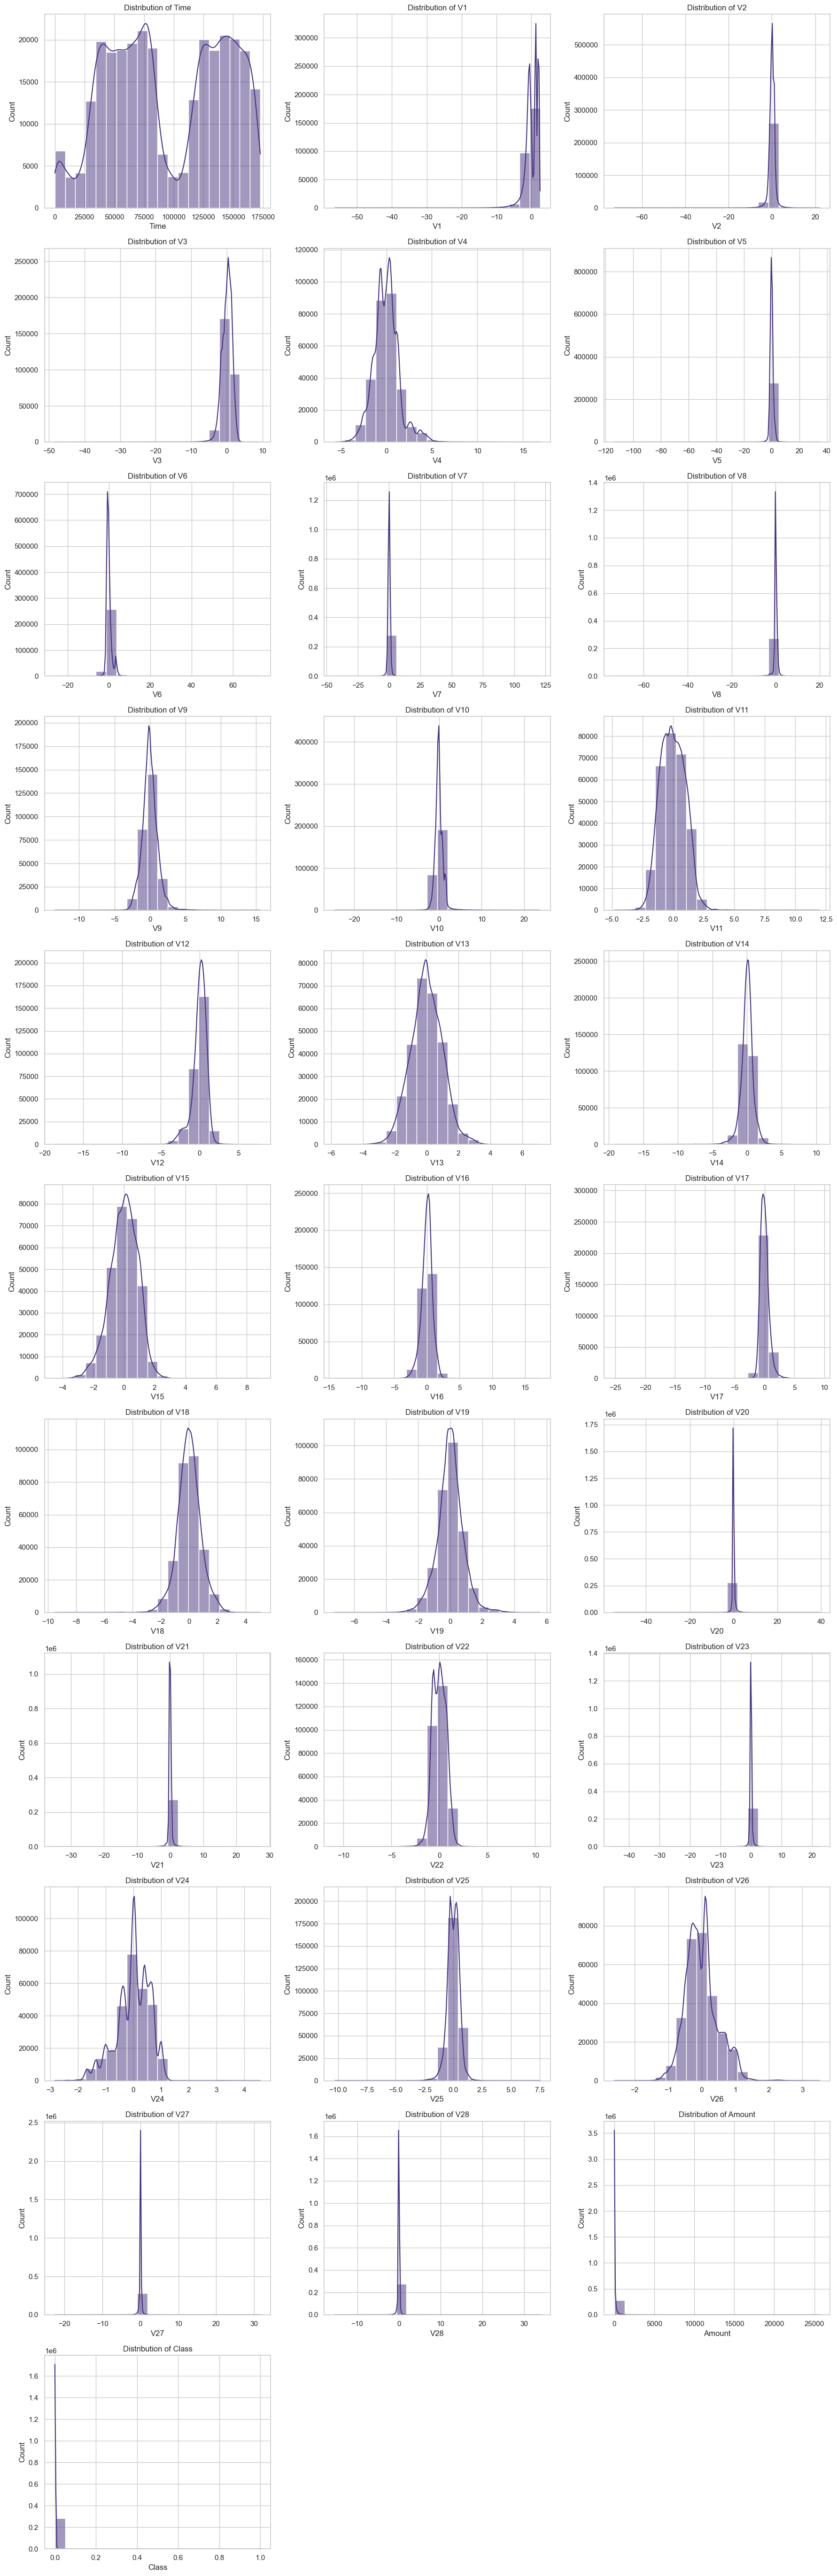

In [75]:
# Global Distribution Histograms
cols = df.columns
n_cols = 3
n_rows = math.ceil(len(cols) / n_cols)
plt.figure(figsize=(18, 5 * n_rows))

for i, col in enumerate(cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

### 📊 Time & Amount Distributions
Looking specifically at when transactions happen and how much they are for.

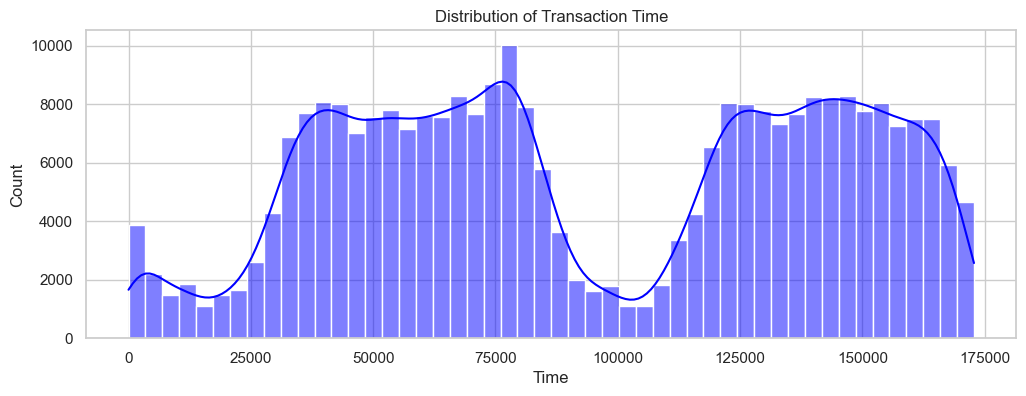

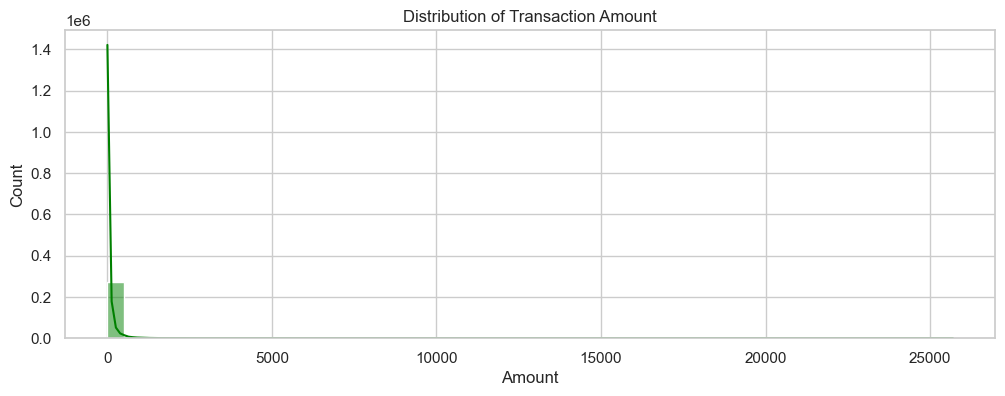

In [76]:
# Chart for distribution of transaction Time
plt.figure(figsize=(12, 4))
sns.histplot(df['Time'], kde=True, color='blue', bins=50)
plt.title('Distribution of Transaction Time')
plt.show()

# Chart for distribution of transaction Amount
plt.figure(figsize=(12, 4))
sns.histplot(df['Amount'], kde=True, color='green', bins=50)
plt.title('Distribution of Transaction Amount')
plt.show()

### 📝 Data Shape Report
A statistical look at how symmetrical or lopsided our data columns are.

In [77]:
# Skewness and Kurtosis for each feature
print("--- Skewness & Kurtosis Report ---")
for col in df:
    print(f'{col}:')
    print(f'  Skewness: {df[col].skew():.4f}')
    print(f'  Kurtosis: {df[col].kurt():.4f}')
    print()

--- Skewness & Kurtosis Report ---
Time:
  Skewness: -0.0356
  Kurtosis: -1.2934

V1:
  Skewness: -3.2733
  Kurtosis: 32.7273

V2:
  Skewness: -4.6952
  Kurtosis: 96.8982

V3:
  Skewness: -2.1520
  Kurtosis: 25.1865

V4:
  Skewness: 0.6715
  Kurtosis: 2.6188

V5:
  Skewness: -2.4141
  Kurtosis: 209.2775

V6:
  Skewness: 1.8299
  Kurtosis: 42.8389

V7:
  Skewness: 2.8903
  Kurtosis: 414.1422

V8:
  Skewness: -8.3110
  Kurtosis: 215.0169

V9:
  Skewness: 0.5377
  Kurtosis: 3.5167

V10:
  Skewness: 1.2530
  Kurtosis: 29.8439

V11:
  Skewness: 0.3441
  Kurtosis: 1.5468

V12:
  Skewness: -2.1990
  Kurtosis: 18.9416

V13:
  Skewness: 0.0643
  Kurtosis: 0.1958

V14:
  Skewness: -1.9188
  Kurtosis: 23.0415

V15:
  Skewness: -0.3097
  Kurtosis: 0.2864

V16:
  Skewness: -1.0512
  Kurtosis: 9.8500

V17:
  Skewness: -3.6905
  Kurtosis: 93.3231

V18:
  Skewness: -0.2487
  Kurtosis: 2.5091

V19:
  Skewness: 0.1083
  Kurtosis: 1.7269

V20:
  Skewness: -2.0431
  Kurtosis: 273.2229

V21:
  Skewness: 2.

### 🔗 Identifying Relationships
These color-coded maps show which data points move together. We specifically look for which features have the strongest connection to the 'Class' (whether it is fraud or not).

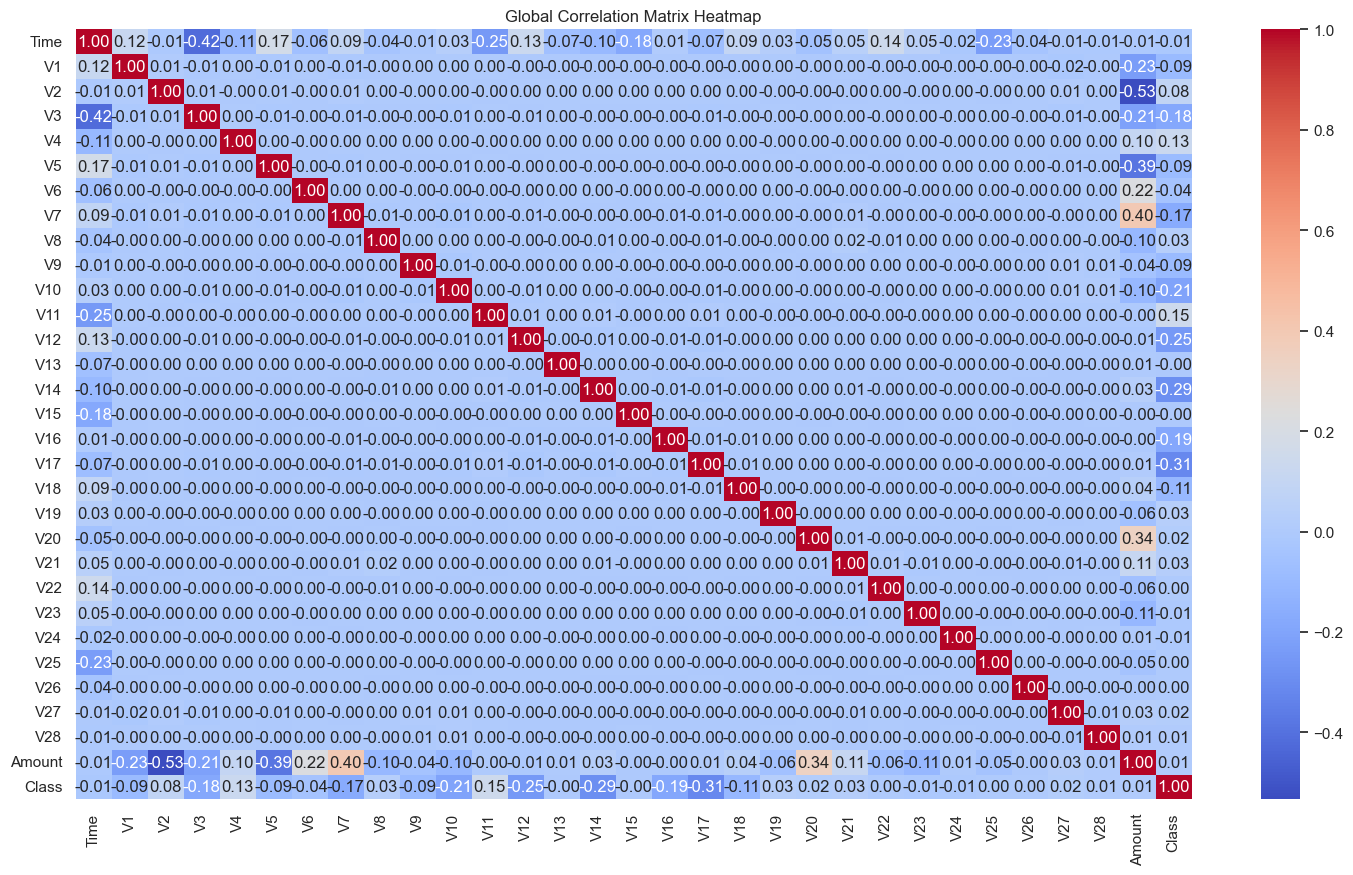

In [78]:
# Full Correlation matrix Heatmap
corr = df.corr()
plt.figure(figsize=(18, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Global Correlation Matrix Heatmap')
plt.show()

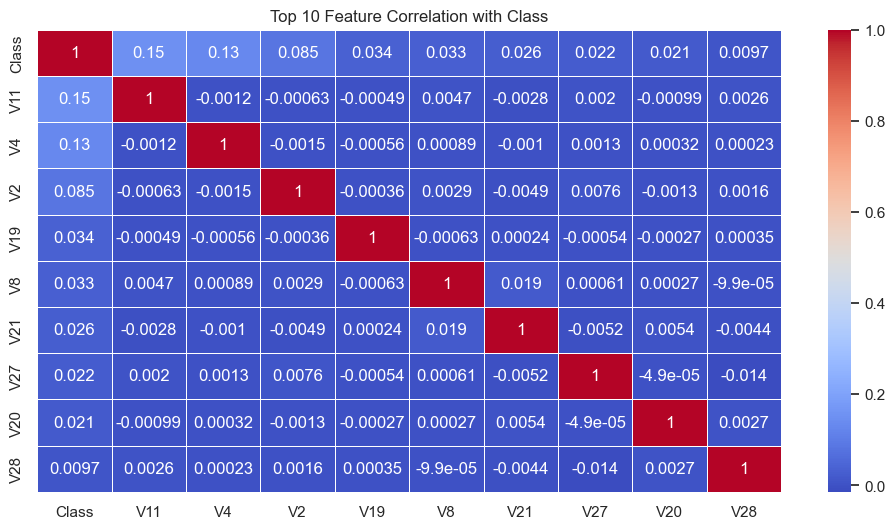

In [79]:
# Top 10 features affecting the target (Class)
top_corr = df.corr()['Class'].sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.heatmap(df[top_corr.index].corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Top 10 Feature Correlation with Class')
plt.show()

### 🔍 Transaction Amount Analysis
Plotting each feature against the transaction amount to see where fraud clusters.

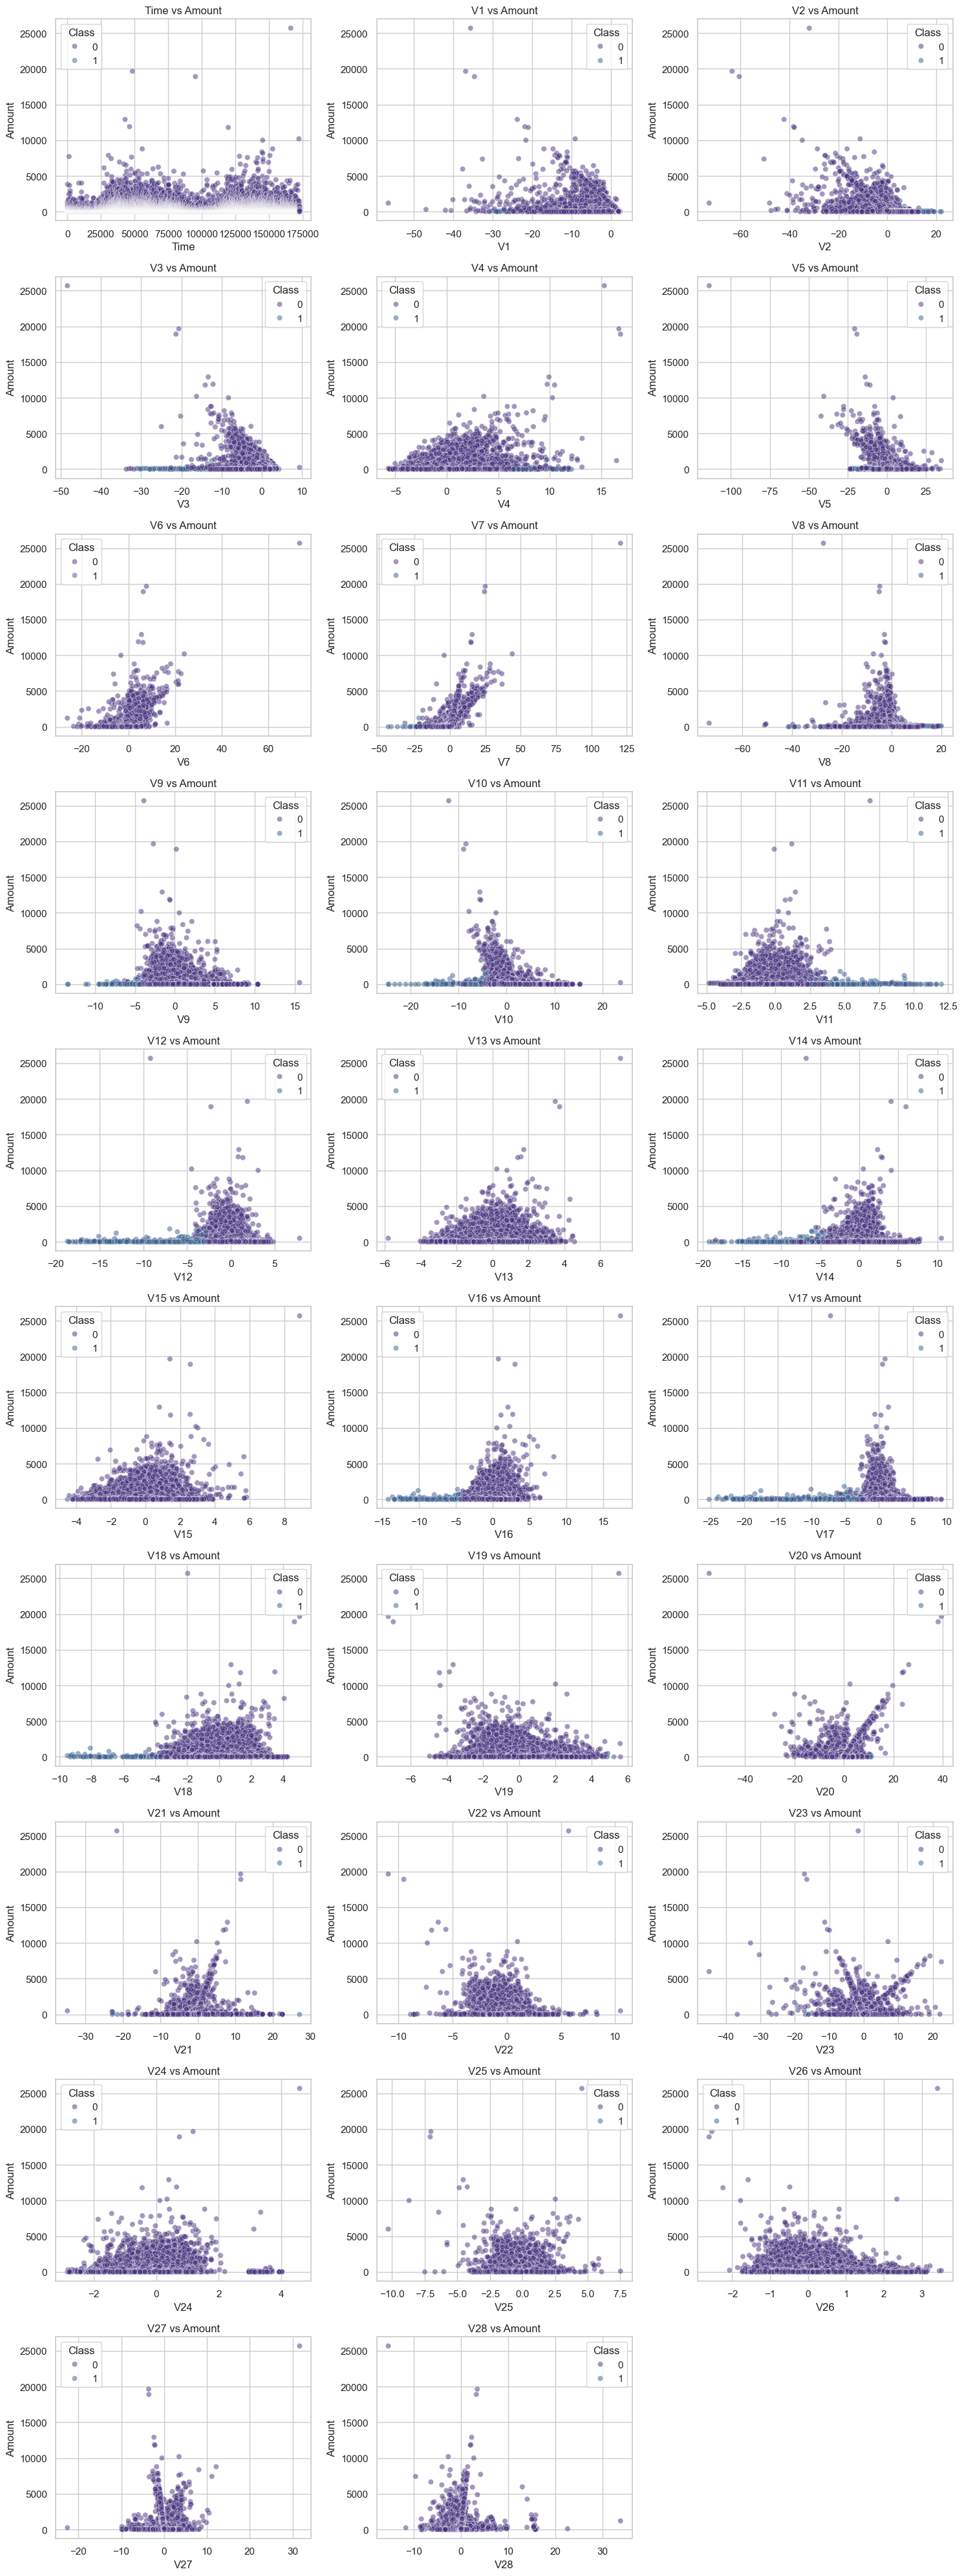

In [80]:
# Scatter plots vs Amount
cols_scatter = [col for col in df if col != 'Amount' and col != 'Class']
n_cols = 3
n_rows = (len(cols_scatter) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(cols_scatter):
    sns.scatterplot(data=df, x=col, y='Amount', hue='Class', ax=axes[i], alpha=0.5)
    axes[i].set_title(f'{col} vs Amount')

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 🌐 3D Exploration
An interactive 3D map of the data to visually locate where the fraudulent transactions hide among normal ones.

In [81]:
# 3D Interactive Scatter Plot
fig = px.scatter_3d(df.sample(min(10000, len(df))), # Sampling for performance in interactive plot
                    x='Amount',
                    y='Time',
                    z='V1',
                    color='Class',
                    size='Amount',
                    title='3D Interactive Scatter Plot (Sampled 10k points)')

fig.update_layout(scene = dict(
                    xaxis_title='Amount',
                    yaxis_title='Time',
                    zaxis_title='Feature V1'))

fig.show()

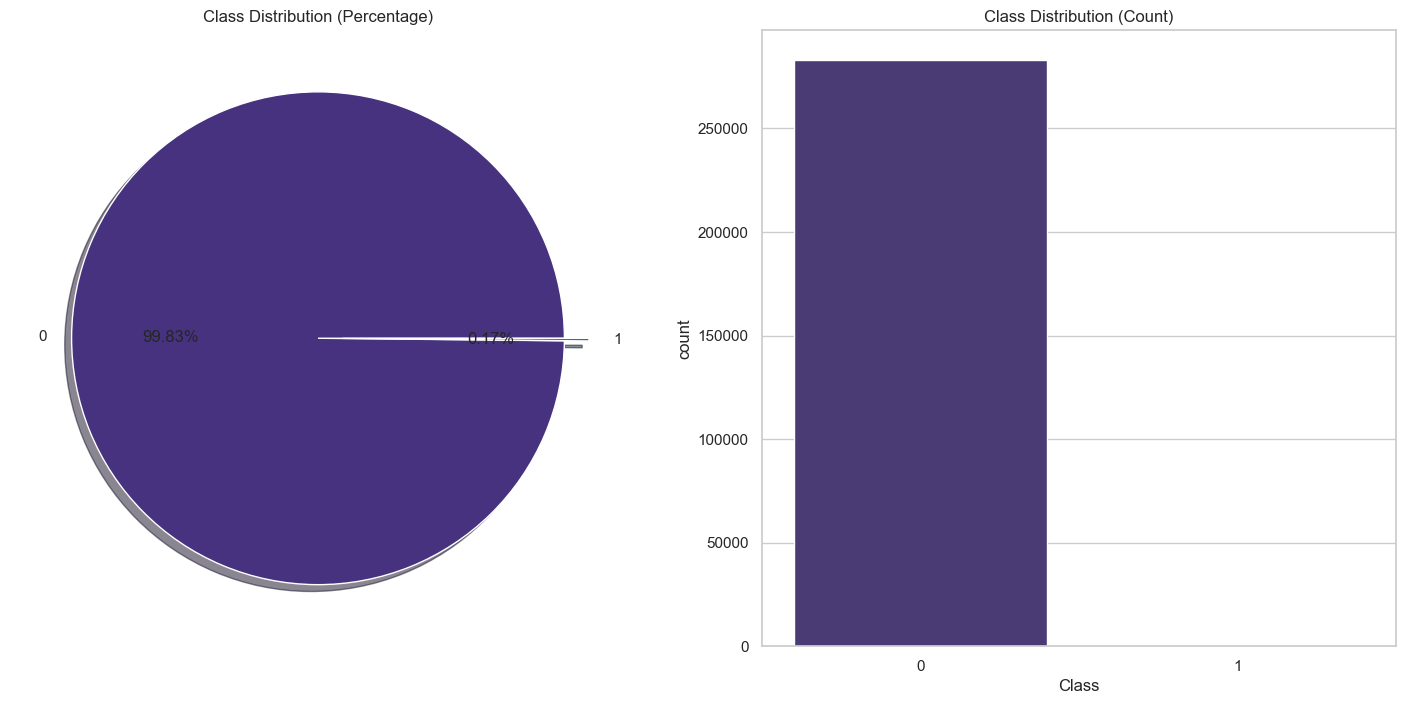

Class Distribution:
Class
0    283253
1       473
Name: count, dtype: int64


In [82]:
f, ax = plt.subplots(1, 2, figsize=(18, 8))

df['Class'].value_counts().plot.pie(explode=[0, 0.1], autopct='%1.2f%%', ax=ax[0], shadow=True)
ax[0].set_title('Class Distribution (Percentage)')
ax[0].set_ylabel('')

sns.countplot(x='Class', data=df, ax=ax[1])
ax[1].set_title('Class Distribution (Count)')
plt.show()

print(f"Class Distribution:\n{df['Class'].value_counts()}")

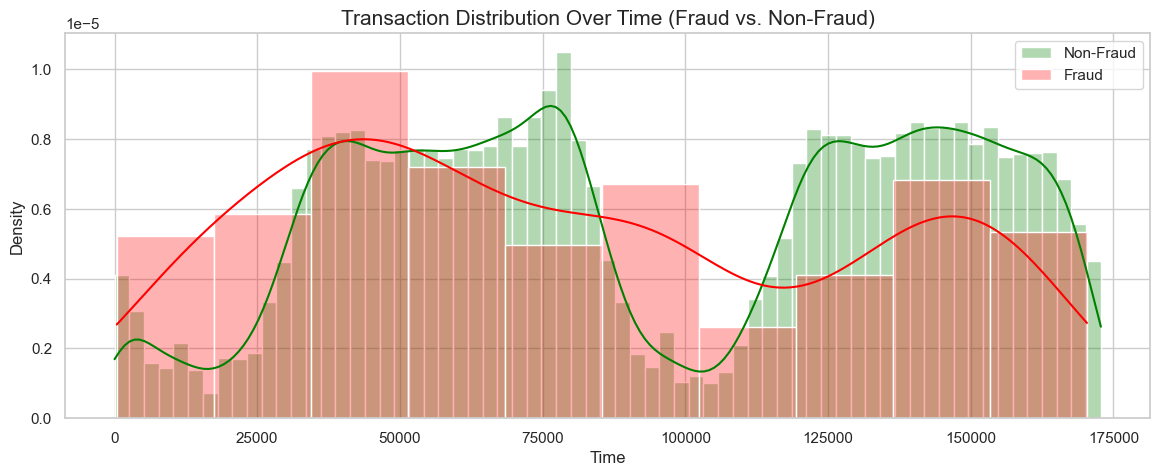

In [83]:
# Advanced Time Pattern Analysis
plt.figure(figsize=(14, 5))
sns.histplot(df[df['Class'] == 0]['Time'], color='g', label='Non-Fraud', kde=True, stat="density", alpha=0.3)
sns.histplot(df[df['Class'] == 1]['Time'], color='r', label='Fraud', kde=True, stat="density", alpha=0.3)
plt.title('Transaction Distribution Over Time (Fraud vs. Non-Fraud)', fontsize=15)
plt.legend()
plt.show()

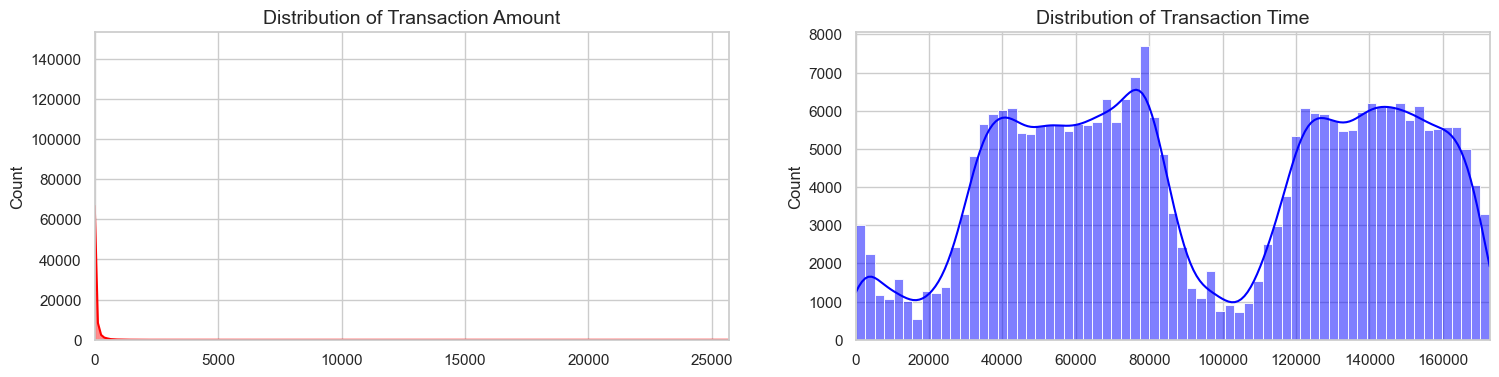

In [84]:
fig, ax = plt.subplots(1, 2, figsize=(18, 4))

amount_val = df['Amount'].values
time_val = df['Time'].values

sns.histplot(amount_val, ax=ax[0], color='r', kde=True)
ax[0].set_title('Distribution of Transaction Amount', fontsize=14)
ax[0].set_xlim([min(amount_val), max(amount_val)])

sns.histplot(time_val, ax=ax[1], color='b', kde=True)
ax[1].set_title('Distribution of Transaction Time', fontsize=14)
ax[1].set_xlim([min(time_val), max(time_val)])

plt.show()

### 🔗 How Features Connect to Fraud
Here we check which columns in our data have the strongest link to whether a transaction is fraudulent. Features with a strong connection will be the most valuable for our models.

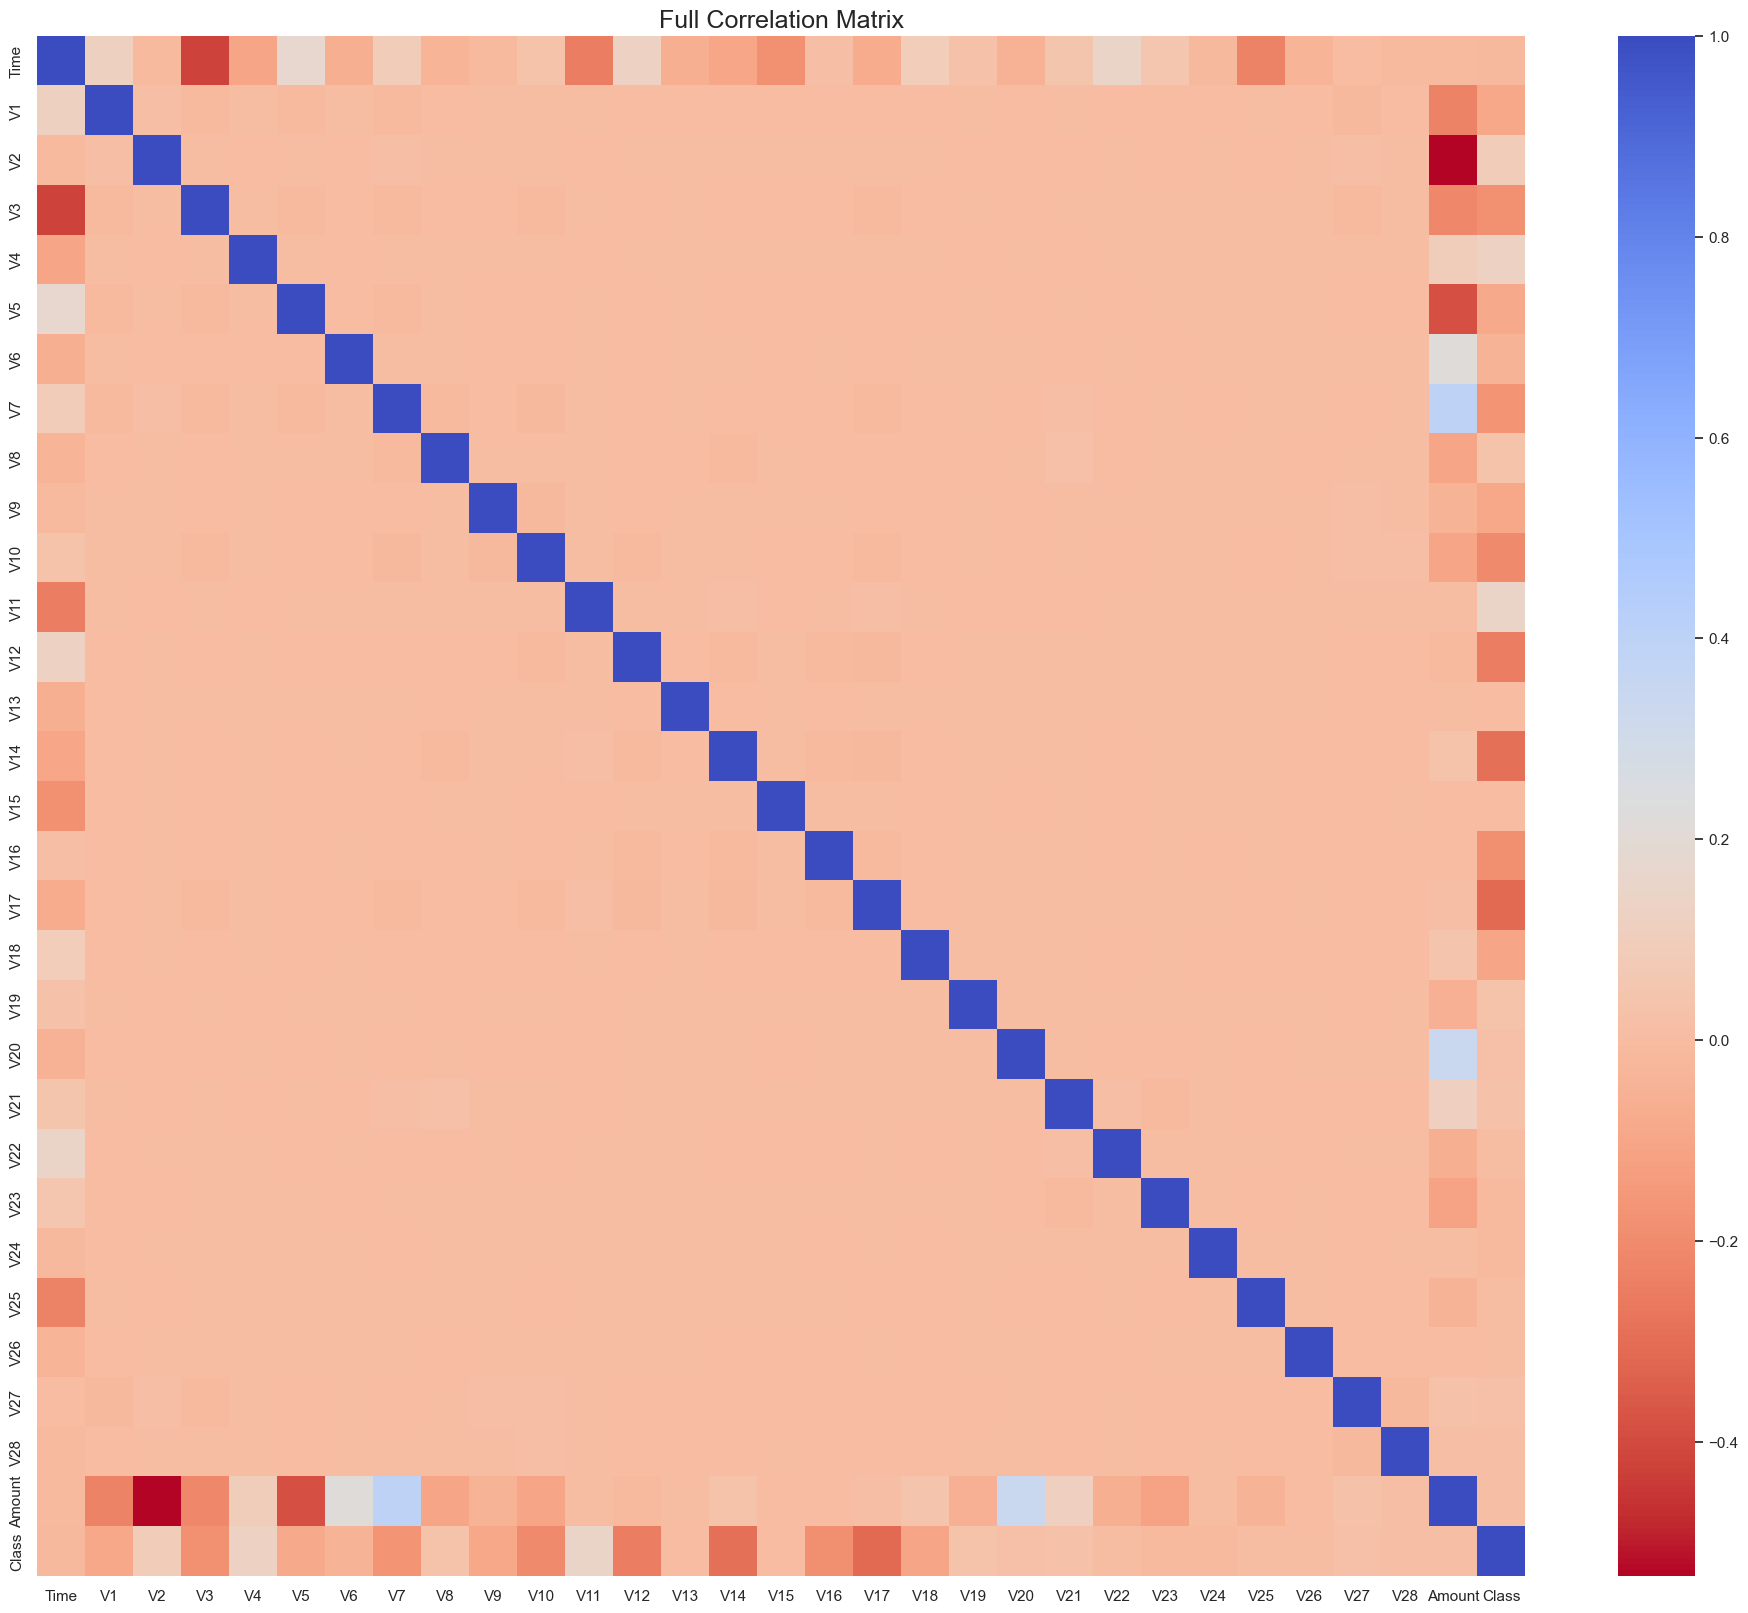

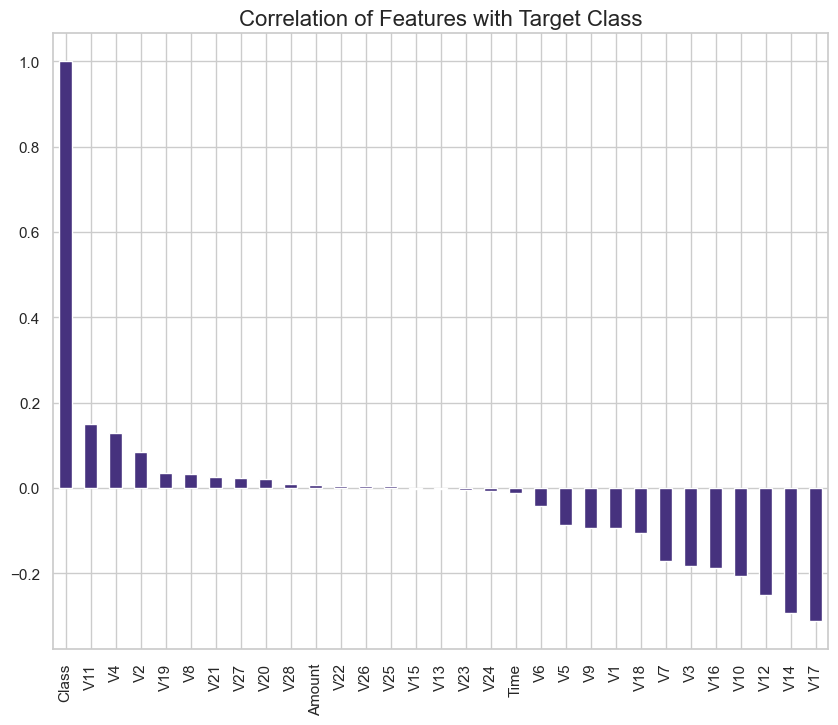

In [85]:
f, ax = plt.subplots(figsize=(24, 20))

corr = df.corr()
sns.heatmap(corr, cmap='coolwarm_r', annot_kws={'size':20}, ax=ax)
ax.set_title("Full Correlation Matrix", fontsize=18)
plt.show()

# Targeted Correlation
plt.figure(figsize=(10, 8))
df.corr()['Class'].sort_values(ascending=False).plot(kind='bar')
plt.title('Correlation of Features with Target Class', fontsize=16)
plt.show()

### 📦 Spotting Unusual Values in Key Columns
For the columns most connected to fraud, we look at how their values are spread out. This helps us spot extreme values that could confuse our models.

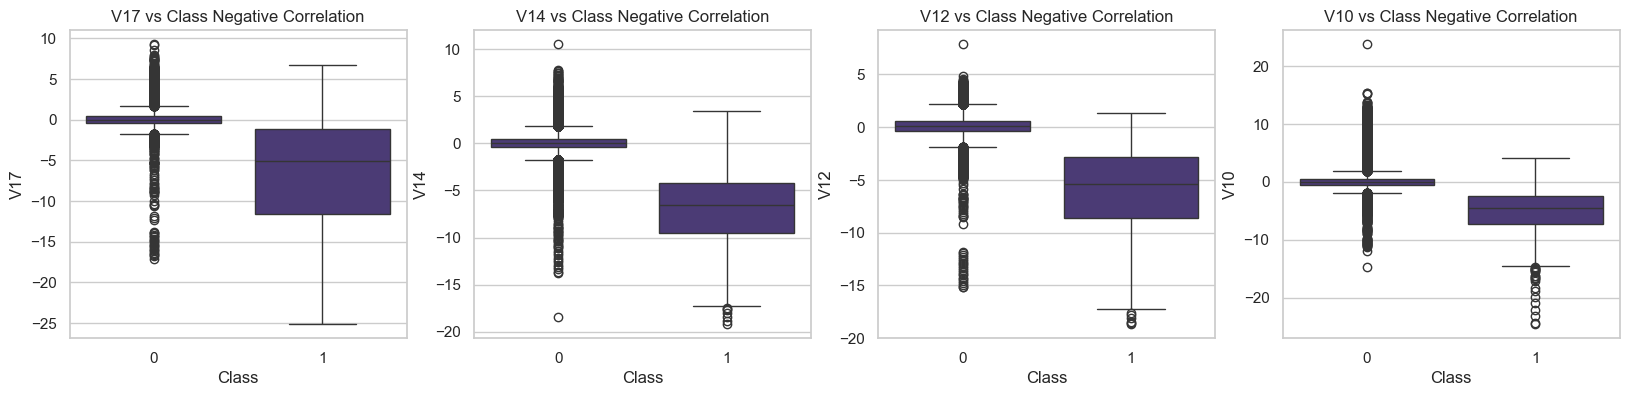

In [86]:
f, axes = plt.subplots(ncols=4, figsize=(20, 4))

# Negative Correlations with our Class (The lower our feature value the more likely it will be a fraud transaction)
sns.boxplot(x="Class", y="V17", data=df, ax=axes[0])
axes[0].set_title('V17 vs Class Negative Correlation')

sns.boxplot(x="Class", y="V14", data=df, ax=axes[1])
axes[1].set_title('V14 vs Class Negative Correlation')

sns.boxplot(x="Class", y="V12", data=df, ax=axes[2])
axes[2].set_title('V12 vs Class Negative Correlation')

sns.boxplot(x="Class", y="V10", data=df, ax=axes[3])
axes[3].set_title('V10 vs Class Negative Correlation')

plt.show()

---
## 📈 Section 3 — Checking for Redundant Columns
Before we train any model, we check whether any two columns in our data are essentially saying the same thing. If they are, one of them is wasted — and it can sometimes confuse the model. This step confirms our data columns are each contributing something unique.

Calculating Variance Inflation Factor (VIF)...
VIF Results:
   variables        VIF
29    Amount  11.650240
2         V2   3.903164
5         V5   2.757256
7         V7   2.504461
0       Time   2.352783
20       V20   2.239605
1         V1   1.624955
6         V6   1.528109
3         V3   1.256154
23       V23   1.154552
4         V4   1.141139
10       V10   1.114508
21       V21   1.100434
8         V8   1.098777
22       V22   1.083646
19       V19   1.038012
11       V11   1.029512
14       V14   1.027096
9         V9   1.019334
15       V15   1.014514
25       V25   1.013613
12       V12   1.012571
27       V27   1.010059
18       V18   1.007009
17       V17   1.005537
13       V13   1.003473
28       V28   1.001721
16       V16   1.000847
24       V24   1.000682
26       V26   1.000516


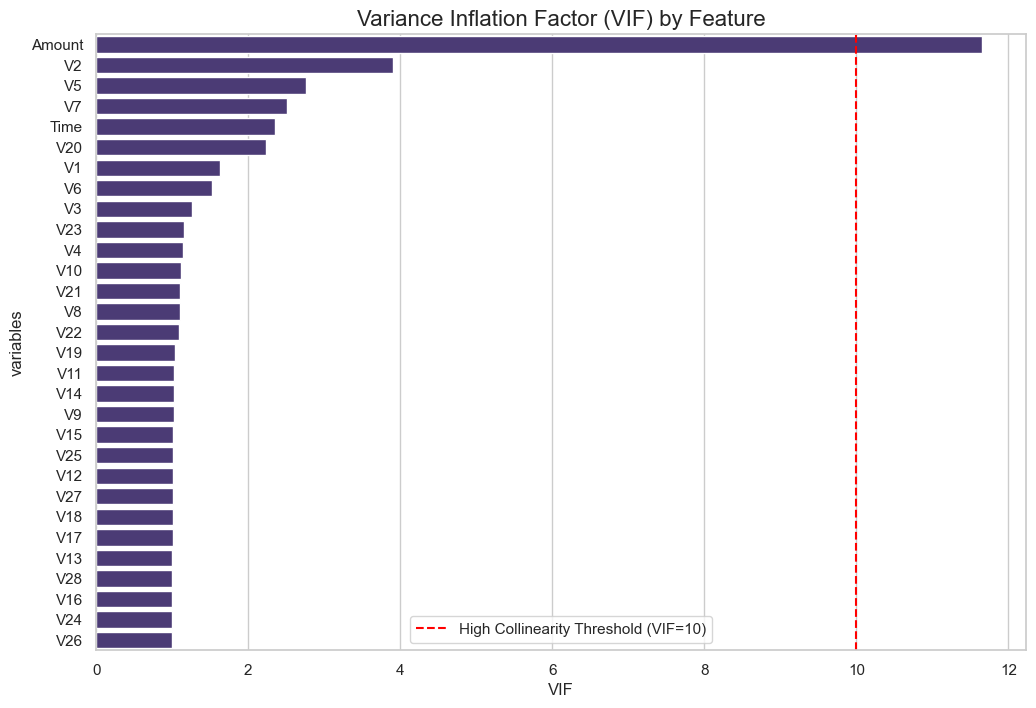

In [87]:
def calculate_vif(X):
    vif = pd.DataFrame()
    vif["variables"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif

print("Calculating Variance Inflation Factor (VIF)...")
# Exclude target variable for VIF
features_vif = df.drop(['Class'], axis=1)
vif_data = calculate_vif(features_vif)

print("VIF Results:")
print(vif_data.sort_values(by='VIF', ascending=False))

# Visualization of VIF scores
plt.figure(figsize=(12, 8))
sns.barplot(x='VIF', y='variables', data=vif_data.sort_values(by='VIF', ascending=False))
plt.axvline(x=10, color='r', linestyle='--', label='High Collinearity Threshold (VIF=10)')
plt.title('Variance Inflation Factor (VIF) by Feature', fontsize=16)
plt.legend()
plt.show()

---
## 🛠️ Section 4 — Data Preprocessing
Before training, we need to transform our data. We scale down large numbers (like transaction amounts) so they are easier for the models to process. We also remove extreme, unusual data points (outliers) that might mislead our models.

In [88]:
print("Scaling features...")
rob_scaler = RobustScaler()
std_scaler = StandardScaler()

df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = std_scaler.fit_transform(df['Time'].values.reshape(-1,1))

df.drop(['Time','Amount'], axis=1, inplace=True)

scaled_amount = df['scaled_amount']
scaled_time = df['scaled_time']

df.drop(['scaled_amount', 'scaled_time'], axis=1, inplace=True)
df.insert(0, 'scaled_amount', scaled_amount)
df.insert(1, 'scaled_time', scaled_time)

print("✅ Scaling complete.")
df.head()

Scaling features...
✅ Scaling complete.


,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,1.774718,-1.996823,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.268530,-1.996823,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,4.959811,-1.996802,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,1.411487,-1.996802,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,0.667362,-1.996781,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0


In [89]:
print("Implementing IQR Outlier Removal for high-correlation features (V14, V12, V10)...")

def remove_outliers(df, feature):
    fraud_feat = df[feature].loc[df['Class'] == 1].values
    q25, q75 = np.percentile(fraud_feat, 25), np.percentile(fraud_feat, 75)
    iqr = q75 - q25
    
    cut_off = iqr * 1.5
    lower, upper = q25 - cut_off, q75 + cut_off
    
    outliers = [x for x in fraud_feat if x < lower or x > upper]
    print(f'Feature {feature} Outliers for Fraud Cases: {len(outliers)}')
    
    df = df.drop(df[(df[feature] > upper) | (df[feature] < lower)].index)
    return df

for feat in ['V14', 'V12', 'V10']:
    df = remove_outliers(df, feat)

print(f"✅ Outlier removal complete. New shape: {df.shape}")

Implementing IQR Outlier Removal for high-correlation features (V14, V12, V10)...
Feature V14 Outliers for Fraud Cases: 7
Feature V12 Outliers for Fraud Cases: 7
Feature V10 Outliers for Fraud Cases: 29
✅ Outlier removal complete. New shape: (281650, 31)


In [90]:
print("Creating interaction features...")
# High signal interaction based on Notebook 1 research
df['V17_x_V14'] = df['V17'] * df['V14']
df['V12_x_V10'] = df['V12'] * df['V10']

print("✅ Feature engineering complete.")

Creating interaction features...
✅ Feature engineering complete.


---
## 🧪 Section 5 — Balancing the Data
Since fraud only makes up about 0.17% of our data, our models might just guess 'Not Fraud' every time. Here, we try two methods to fix this: creating synthetic fraud examples (SMOTE) and reducing the number of normal examples (Under-sampling).

In [91]:
X = df.drop('Class', axis=1)
y = df['Class']

# Stratified Train-Test Split (BEFORE SMOTE to avoid leakage)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Original Distribution: {Counter(y_train)}")

Original Distribution: Counter({0: 224976, 1: 344})


Under-sampled Distribution: Counter({0: 344, 1: 344})
SMOTE Distribution: Counter({0: 224976, 1: 224976})


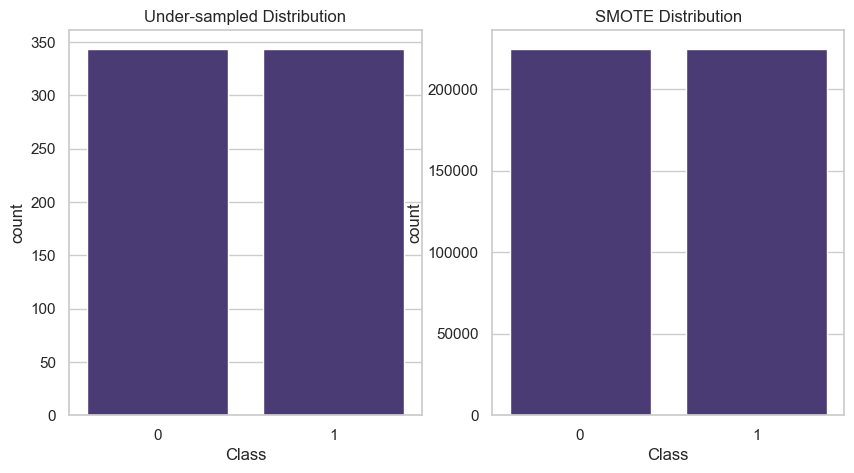

In [92]:
# Under-sampling
rus = RandomUnderSampler(random_state=42)
X_under, y_under = rus.fit_resample(X_train, y_train)
print(f"Under-sampled Distribution: {Counter(y_under)}")

# SMOTE Over-sampling
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train)
print(f"SMOTE Distribution: {Counter(y_smote)}")

# Visualization of result
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.countplot(x=y_under)
plt.title('Under-sampled Distribution')

plt.subplot(1, 2, 2)
sns.countplot(x=y_smote)
plt.title('SMOTE Distribution')
plt.show()

---
## 🤖 Section 6 — Training the Models
Here we train six different models on our balanced data and collect their predictions. We start with simple approaches (Logistic Regression), move to powerful tree-based methods (Random Forest, XGBoost, LightGBM), then a Neural Network, and finally combine the best models together into one 'Stacking' model that votes on the final answer.

In [93]:
print("Training models on SMOTE data...")

# 1. Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_smote, y_smote)
lr_probs = lr_model.predict_proba(X_test)[:, 1]

# 2. Random Forest
rf_model = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
rf_model.fit(X_smote, y_smote)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# 3. XGBoost
xgb_model = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_model.fit(X_smote, y_smote)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

# 4. LightGBM
lgbm_model = LGBMClassifier(random_state=42)
lgbm_model.fit(X_smote, y_smote)
lgbm_probs = lgbm_model.predict_proba(X_test)[:, 1]

print("✅ Basic models trained.")

Training models on SMOTE data...
[LightGBM] [Info] Number of positive: 224976, number of negative: 224976
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.044196 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8160
[LightGBM] [Info] Number of data points in the train set: 449952, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
✅ Basic models trained.


In [94]:
print("Fine-tuning XGBoost with RandomizedSearchCV...")
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9]
}

rs_xgb = RandomizedSearchCV(XGBClassifier(eval_metric='logloss'), param_grid, n_iter=5, cv=3, scoring='average_precision', n_jobs=-1, random_state=42)
rs_xgb.fit(X_smote, y_smote)

best_xgb = rs_xgb.best_estimator_
print(f"✅ Best XGB Params: {rs_xgb.best_params_}")

Fine-tuning XGBoost with RandomizedSearchCV...
✅ Best XGB Params: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 10, 'learning_rate': 0.2}


In [95]:
if HAS_TF:
    # --- TensorFlow Implementation ---
        print("Training Neural Network (TensorFlow/Keras)...")
        
        nn_model = Sequential([
            Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
            Dropout(0.2),
            Dense(16, activation='relu'),
            Dense(1, activation='sigmoid')
        ])
        
        nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
        
        history = nn_model.fit(X_smote, y_smote, epochs=20, batch_size=256, validation_split=0.2, 
                            callbacks=[EarlyStopping(patience=3)], verbose=0)
        
        nn_probs = nn_model.predict(X_test).flatten()
        print("✅ Neural Network training complete.")
else:
    # --- Scikit-Learn Fallback (MLP) ---
    print('Training MLPClassifier (Scikit-Learn) as TF fallback...')
    nn_model = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=20, alpha=1e-4,
                            solver='adam', verbose=False, random_state=42,
                            batch_size=256)
    nn_model.fit(X_smote, y_smote)
    nn_probs = nn_model.predict_proba(X_test)[:, 1]
    print('✅ MLP training complete.')

Training MLPClassifier (Scikit-Learn) as TF fallback...
✅ MLP training complete.


In [96]:
print("Building Stacking Ensemble...")
estimators = [
    ('rf', rf_model),
    ('lgbm', lgbm_model),
    ('xgb', best_xgb)
]

stack_model = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression(), cv=3, n_jobs=-1)
stack_model.fit(X_smote, y_smote)
stack_probs = stack_model.predict_proba(X_test)[:, 1]

print("✅ Stacking Ensemble training complete.")

Building Stacking Ensemble...
✅ Stacking Ensemble training complete.


---
## 📊 Section 7 — Comparing All Models
We now measure every model using six different scores:
- **Accuracy** — Out of all transactions, how many did it get right?
- **Precision** — Of the transactions it flagged as fraud, how many were actually fraud?
- **Recall** — Of all the real fraud cases, how many did it actually catch?
- **F1-Score** — A single number that balances Precision and Recall.
- **ROC-AUC** — How well the model separates fraud from normal across all possible cut-off points.
- **AUPRC** — The most reliable score for rare-event detection like fraud.

We also show a Precision-Recall chart, a Confusion Matrix (a grid of correct vs. wrong answers), and a detailed breakdown per model.

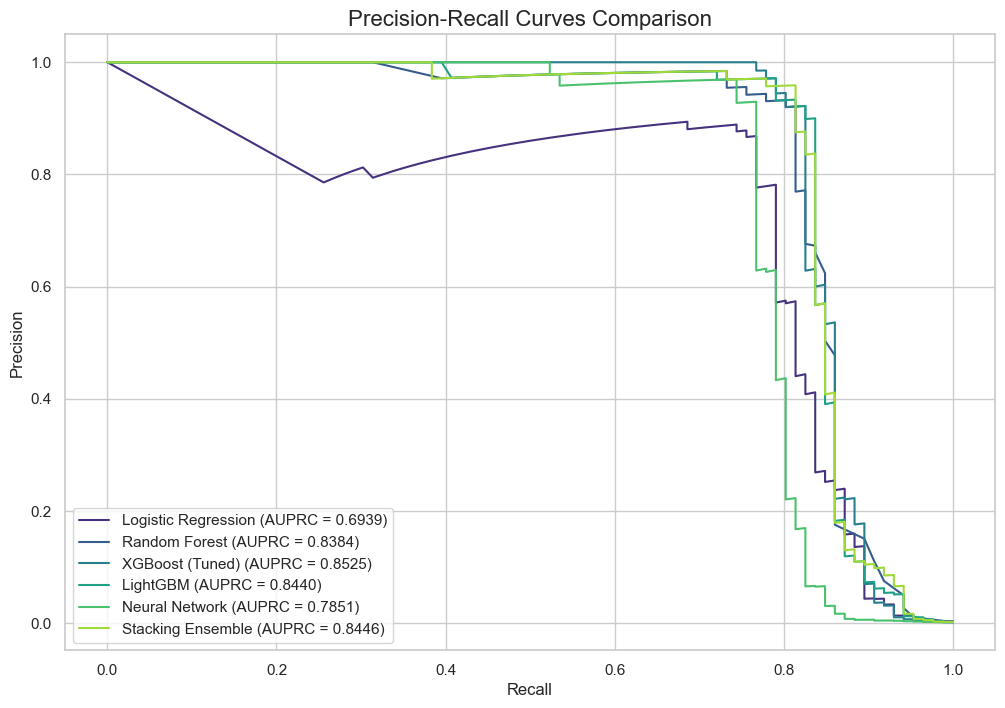

In [97]:
models = {
    'Logistic Regression': lr_probs,
    'Random Forest': rf_probs,
    'XGBoost (Tuned)': xgb_probs,
    'LightGBM': lgbm_probs,
    'Neural Network': nn_probs,
    'Stacking Ensemble': stack_probs
}

plt.figure(figsize=(12, 8))
for name, probs in models.items():
    precision, recall, _ = precision_recall_curve(y_test, probs)
    auprc = average_precision_score(y_test, probs)
    plt.plot(recall, precision, label=f'{name} (AUPRC = {auprc:.4f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves Comparison', fontsize=16)
plt.legend()
plt.show()

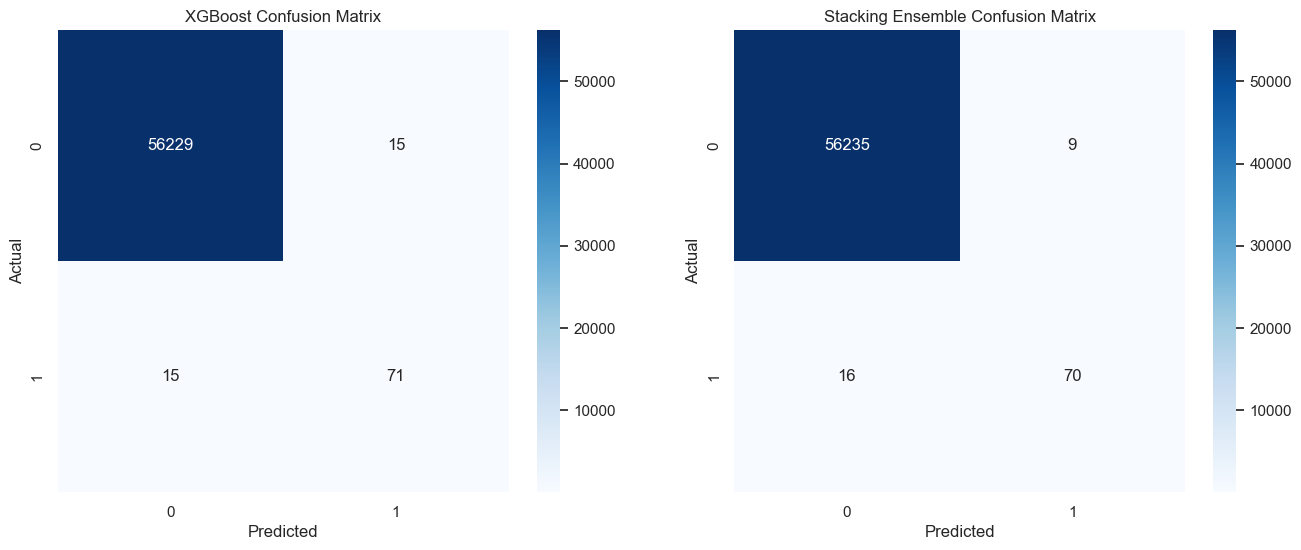

In [98]:
def plot_confusion_matrix(y_true, y_pred_probs, title, ax):
    y_pred = (y_pred_probs > 0.5).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_confusion_matrix(y_test, xgb_probs, 'XGBoost Confusion Matrix', axes[0])
plot_confusion_matrix(y_test, stack_probs, 'Stacking Ensemble Confusion Matrix', axes[1])
plt.show()

In [99]:
results = []
for name, probs in models.items():
    y_pred = (probs > 0.5).astype(int)

    auprc  = average_precision_score(y_test, probs)
    roc    = roc_auc_score(y_test, probs)
    f1     = f1_score(y_test, y_pred)
    acc    = accuracy_score(y_test, y_pred)

    # Precision and Recall from classification_report dict
    report = classification_report(y_test, y_pred, output_dict=True)
    prec   = report['1']['precision']
    rec    = report['1']['recall']

    results.append({
        'Model':     name,
        'Accuracy':  round(acc,  4),
        'Precision': round(prec, 4),
        'Recall':    round(rec,  4),
        'F1-Score':  round(f1,   4),
        'ROC-AUC':   round(roc,  4),
        'AUPRC':     round(auprc,4),
    })

leaderboard = pd.DataFrame(results).sort_values(by='AUPRC', ascending=False)
print("\n🏆 Full Model Performance Leaderboard:")
print(leaderboard.to_string(index=False))
leaderboard


🏆 Full Model Performance Leaderboard:
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC  AUPRC
    XGBoost (Tuned)    0.9995     0.8256  0.8256    0.8256   0.9718 0.8525
  Stacking Ensemble    0.9996     0.8861  0.8140    0.8485   0.9782 0.8446
           LightGBM    0.9986     0.5252  0.8488    0.6489   0.9794 0.8440
      Random Forest    0.9996     0.9211  0.8140    0.8642   0.9714 0.8384
     Neural Network    0.9992     0.7416  0.7674    0.7543   0.9380 0.7851
Logistic Regression    0.9661     0.0399  0.9186    0.0765   0.9783 0.6939


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,AUPRC
2,XGBoost (Tuned),0.9995,0.8256,0.8256,0.8256,0.9718,0.8525
5,Stacking Ensemble,0.9996,0.8861,0.8140,0.8485,0.9782,0.8446
3,LightGBM,0.9986,0.5252,0.8488,0.6489,0.9794,0.8440
1,Random Forest,0.9996,0.9211,0.8140,0.8642,0.9714,0.8384
4,Neural Network,0.9992,0.7416,0.7674,0.7543,0.9380,0.7851
0,Logistic Regression,0.9661,0.0399,0.9186,0.0765,0.9783,0.6939


### 📋 Detailed Per-Model Reports
For each model, this shows a breakdown of exactly how many fraud cases it caught, missed, and how many normal transactions it incorrectly flagged.

In [100]:
# Print detailed per-class report for each model
for name, probs in models.items():
    y_pred = (probs > 0.5).astype(int)
    print(f"\n{'='*55}")
    print(f"  {name} — Classification Report")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))


  Logistic Regression — Classification Report
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.98     56244
       Fraud       0.04      0.92      0.08        86

    accuracy                           0.97     56330
   macro avg       0.52      0.94      0.53     56330
weighted avg       1.00      0.97      0.98     56330


  Random Forest — Classification Report
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56244
       Fraud       0.92      0.81      0.86        86

    accuracy                           1.00     56330
   macro avg       0.96      0.91      0.93     56330
weighted avg       1.00      1.00      1.00     56330


  XGBoost (Tuned) — Classification Report
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56244
       Fraud       0.83      0.83      0.83        86

    accuracy                           1.00     563

---
## 🔬 Section 8 — Going Deeper
Now that we have our results, we investigate three additional questions:
1. **How well-calibrated are the models?** — When a model says '80% chance of fraud', is it usually right 80% of the time? We check this with a reliability chart.
2. **How did the Neural Network learn?** — We plot the training progress over time to see if the model improved steadily or started overfitting.
3. **What is the best fraud cut-off score?** — Instead of always using 0.5 as the threshold to declare a transaction 'fraud', we find the exact number that gives the best results.

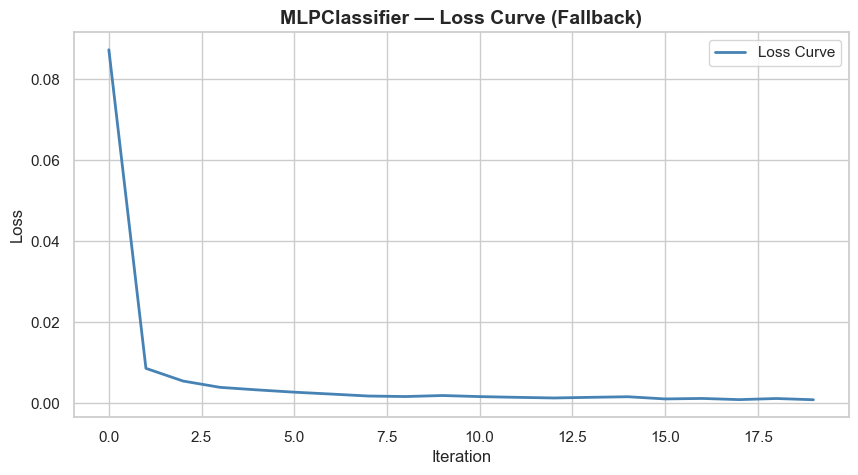

In [101]:

if HAS_TF:
    # --- TensorFlow Learning Curves ---
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Train Loss', linewidth=2, color='steelblue')
    plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color='tomato', linestyle='--')
    plt.title('Neural Network — Training vs. Validation Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()
else:
    # --- MLP Fallback Learning Curves ---
    plt.figure(figsize=(10, 5))
    plt.plot(nn_model.loss_curve_, label='Loss Curve', linewidth=2, color='steelblue')
    plt.title('MLPClassifier — Loss Curve (Fallback)', fontsize=14, fontweight='bold')
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()


Generating Probability Calibration Curves...


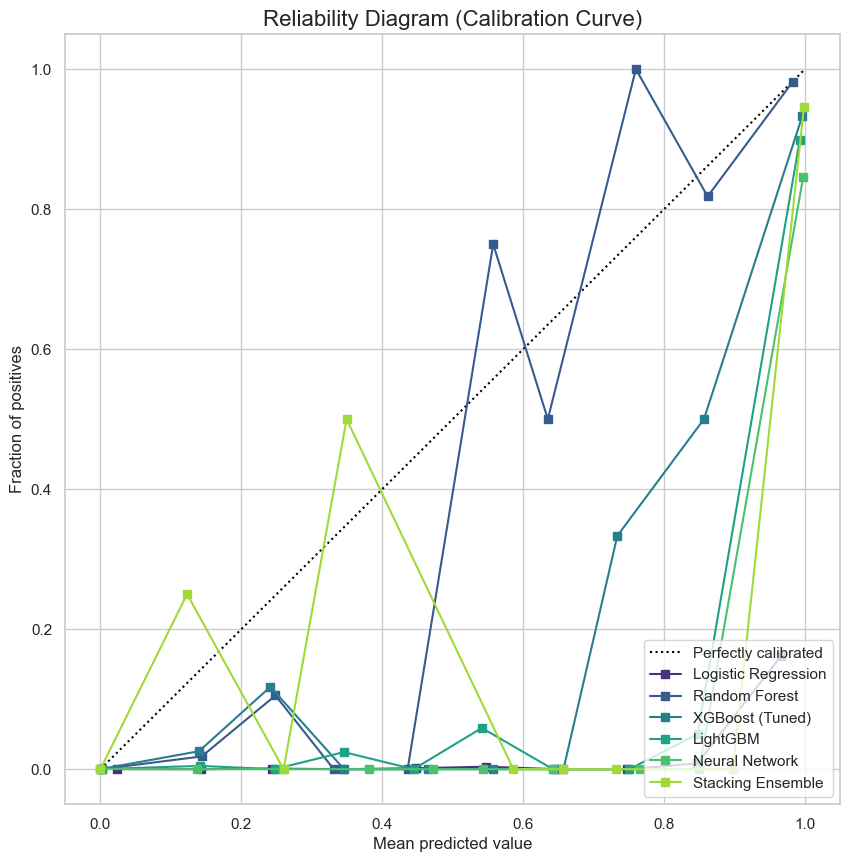

In [102]:
from sklearn.calibration import calibration_curve

print("Generating Probability Calibration Curves...")
plt.figure(figsize=(10, 10))
plt.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")

for name, probs in models.items():
    fraction_of_positives, mean_predicted_value = calibration_curve(y_test, probs, n_bins=10)
    plt.plot(mean_predicted_value, fraction_of_positives, "s-", label=name)

plt.ylabel("Fraction of positives")
plt.xlabel("Mean predicted value")
plt.title("Reliability Diagram (Calibration Curve)", fontsize=16)
plt.legend(loc="lower right")
plt.show()

Finding Optimal Threshold for Stacking Ensemble...


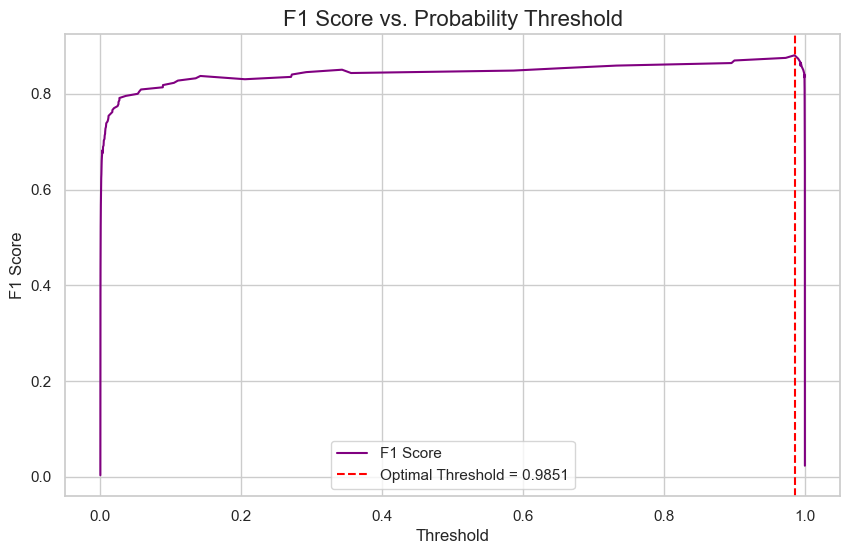

Optimal Threshold: 0.9851 with Max F1: 0.8805


In [103]:
print("Finding Optimal Threshold for Stacking Ensemble...")
precision, recall, thresholds = precision_recall_curve(y_test, stack_probs)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = np.max(f1_scores)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores[:-1], label='F1 Score', color='purple')
plt.axvline(best_threshold, color='r', linestyle='--', label=f'Optimal Threshold = {best_threshold:.4f}')
plt.title('F1 Score vs. Probability Threshold', fontsize=16)
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.legend()
plt.show()

print(f"Optimal Threshold: {best_threshold:.4f} with Max F1: {best_f1:.4f}")

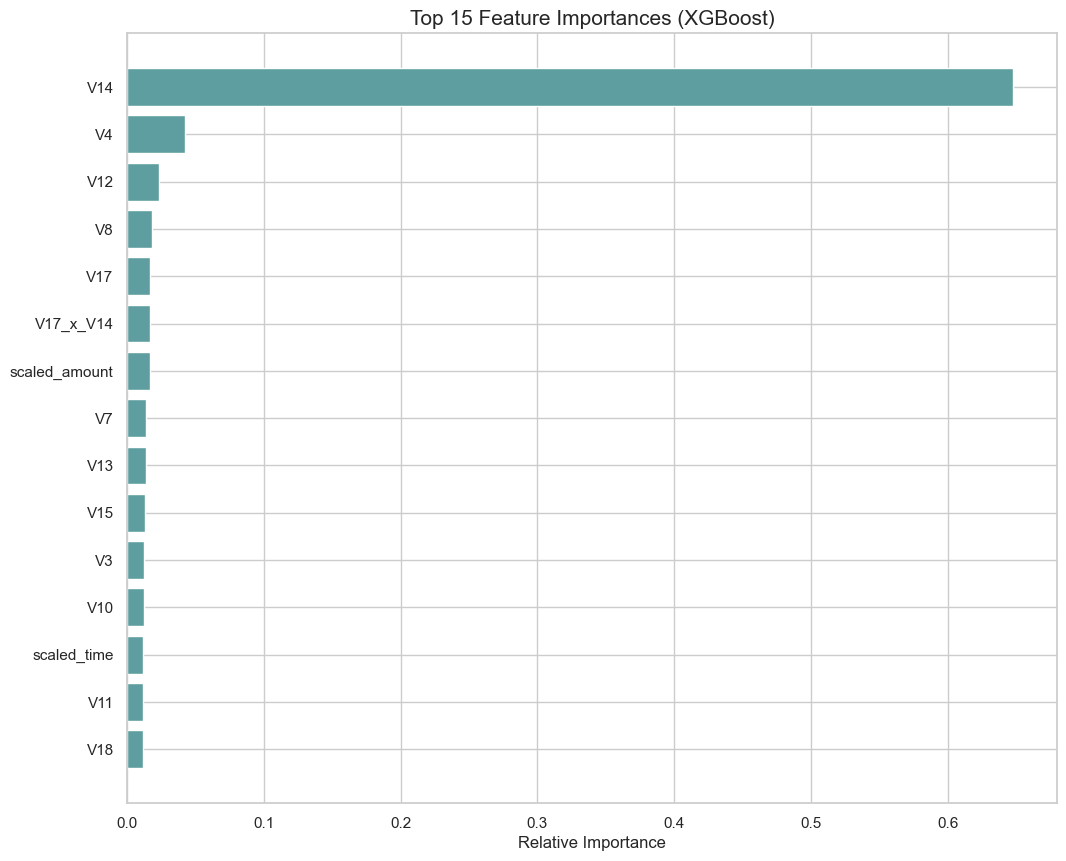

In [104]:
# Feature Importance (XGBoost)
plt.figure(figsize=(12, 10))
importances = best_xgb.feature_importances_
indices = np.argsort(importances)[-15:]
plt.barh(range(len(indices)), importances[indices], color='cadetblue', align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.title('Top 15 Feature Importances (XGBoost)', fontsize=15)
plt.xlabel('Relative Importance')
plt.show()

---
## 🏁 Conclusion
After training and testing six models, stacking our top performers together gave the best overall results — catching more fraud while keeping false alarms low.

### Key Takeaways:
- **High accuracy alone is misleading** — A model that never predicts fraud would still be 99.8% accurate because fraud is so rare. That's why we use Precision, Recall, and the AUPRC score instead.
- **Redundant columns didn't hurt** — Some data columns were similar to each other, but our best models were smart enough to handle that without us needing to remove them.
- **Adjusting the cut-off point helps** — Our models produce a score between 0 and 1. Lowering the threshold from the default 0.5 to a smarter value lets us catch significantly more fraud without flagging too many normal transactions as suspicious.